# BEM test-set RMSE

Recomputes test-set force/torque RMSE with the `measure_bem_RMSE` stack for `processed_data/bem` (baseline).

Metrics: `Fxy=√((Fx²+Fy²)/2)`, `Fz` per-axis, `F=√((Fx²+Fy²+Fz²)/3)`; same for M. Ground truth `f=m·a`, `τ=Iα+ω×Iω` with mass 0.772, inertia [0.00254,0.00214,0.00436] (`measure_bem_RMSE`). Rows filtered to the `testset.txt` hold-out.

In [1]:
import glob
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

NBEM = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "processed_data").exists())
sys.path.insert(0, str(NBEM / "analysis"))
from measure_bem_RMSE import measured, metrics  # the measure-RMSE stack

TEST_IDS = {l.strip() for l in open(NBEM / "testset.txt") if l.strip()}
PROC = NBEM / "processed_data"


def testset_rmse(bem_dir):
    fr, tr, n = [], [], 0
    for f in sorted(glob.glob(str(bem_dir / "*.csv"))):
        fid = os.path.basename(f).split("_", 1)[1][:-4]
        if fid not in TEST_IDS:
            continue
        d = np.loadtxt(f, delimiter=",")
        fm, tm = measured(d)
        fr.append(fm - d[:, 29:32])
        tr.append(tm - d[:, 32:35])
        n += len(d)
    fxy, fz, F = metrics(np.vstack(fr))
    mxy, mz, M = metrics(np.vstack(tr))
    return {"Fxy": fxy, "Fz": fz, "Mxy": mxy, "Mz": mz, "F": F, "M": M, "rows": n}


folders = ["bem"] + sorted(d.name for d in PROC.iterdir() if d.is_dir() and d.name[0].isdigit())
rows = {f: testset_rmse(PROC / f) for f in folders}
{f: r["rows"] for f, r in rows.items()}

{'bem': 215829,
 '2026-07-15-00-00-00': 215829,
 '2026-07-21-14-54-19': 215829,
 '2026-07-22-12-36-31': 215829,
 '2026-07-22-15-14-56': 215829,
 '2026-07-22-18-39-25': 215829,
 '2026-07-23-11-57-11': 215829,
 '2026-07-23-15-54-29': 215829}

In [2]:
PAPER = {
    "paper BEM":    {"Fxy": 0.803, "Fz": 1.265, "Mxy": 0.090, "Mz": 0.017, "F": 0.982, "M": 0.074},
    "paper BEM+NN": {"Fxy": 0.204, "Fz": 0.504, "Mxy": 0.014, "Mz": 0.004, "F": 0.335, "M": 0.012},
}

COLS = ["Fxy", "Fz", "Mxy", "Mz", "F", "M"]
df = pd.DataFrame({**{f: {c: rows[f][c] for c in COLS} for f in folders}, **PAPER}).T[COLS]
df.index.name = "config"

base = df.loc["bem"]  # baseline
df["F impr%"] = (base["F"] - df["F"]) / base["F"] * 100
df["M impr%"] = (base["M"] - df["M"]) / base["M"] * 100
df = df[["Fxy", "Fz", "Mxy", "Mz", "F", "F impr%", "M", "M impr%"]]


def color_impr(col):
    return ["color: #2e7d32" if v > 0 else "color: #c62828" if v < 0 else "" for v in col]


outline = {"border-left": "2px solid #444", "border-right": "2px solid #444"}
(df.style
   .format({"Fxy": "{:.3f}", "Fz": "{:.3f}", "Mxy": "{:.3f}", "Mz": "{:.3f}",
            "F": "{:.3f}", "M": "{:.3f}", "F impr%": "{:+.1f}%", "M impr%": "{:+.1f}%"})
   .set_properties(subset=["F", "M"], **outline)
   .apply(color_impr, subset=["F impr%", "M impr%"])
   .set_table_styles(
       {"F": [{"selector": "th", "props": [("border-left", "2px solid #444"), ("border-right", "2px solid #444")]}],
        "M": [{"selector": "th", "props": [("border-left", "2px solid #444"), ("border-right", "2px solid #444")]}]},
       overwrite=False)
   .set_caption("Test-set RMSE (Table II format) — F/M outlined, impr% vs bem baseline"))

,Fxy,Fz,Mxy,Mz,F,F impr%,M,M impr%
config,,,,,,,,
bem,0.575,1.663,0.127,0.015,1.069,+0.0%,0.104,+0.0%
2026-07-15-00-00-00,0.577,1.612,0.124,0.015,1.043,+2.4%,0.102,+2.5%
2026-07-21-14-54-19,0.397,0.907,0.129,0.014,0.616,+42.4%,0.106,-1.2%
2026-07-22-12-36-31,0.490,1.681,0.026,0.019,1.050,+1.8%,0.024,+77.4%
2026-07-22-15-14-56,0.551,1.625,0.027,0.016,1.040,+2.7%,0.024,+77.4%
2026-07-22-18-39-25,0.829,1.006,0.088,0.009,0.892,+16.6%,0.072,+30.6%
2026-07-23-11-57-11,0.626,1.086,0.084,0.025,0.809,+24.3%,0.070,+33.0%
2026-07-23-15-54-29,0.413,0.899,0.040,0.029,0.619,+42.1%,0.036,+65.2%
paper BEM,0.803,1.265,0.090,0.017,0.982,+8.1%,0.074,+29.0%


## Best / worst test-set segment — measured vs modeled

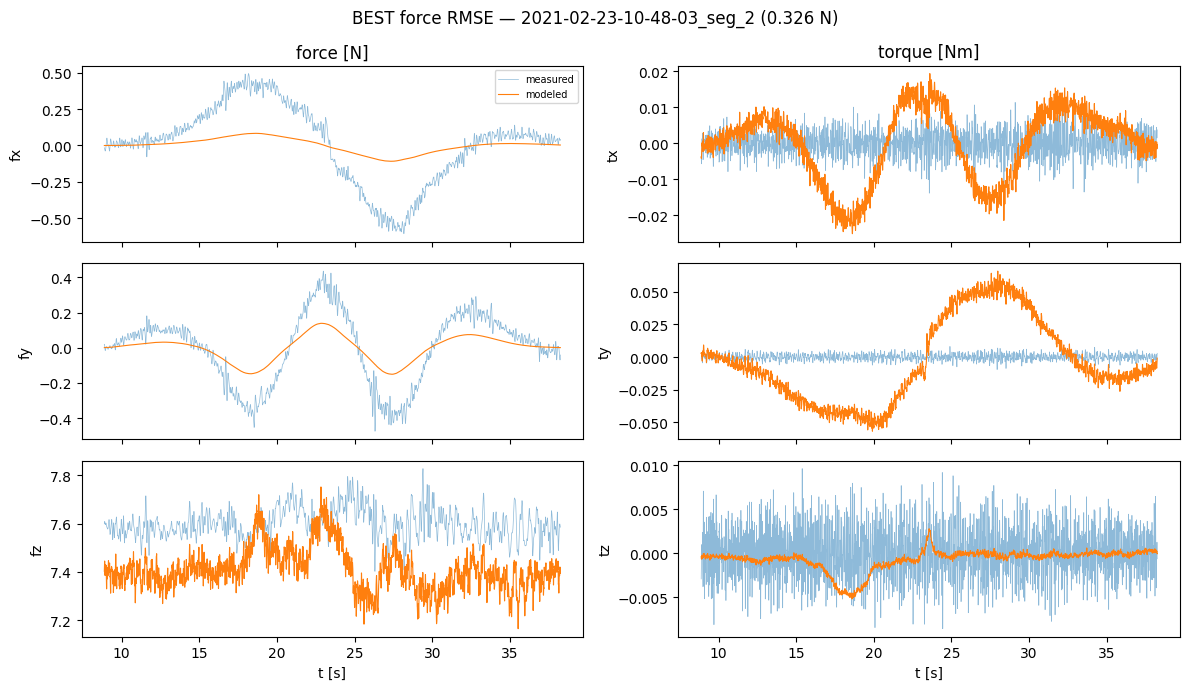

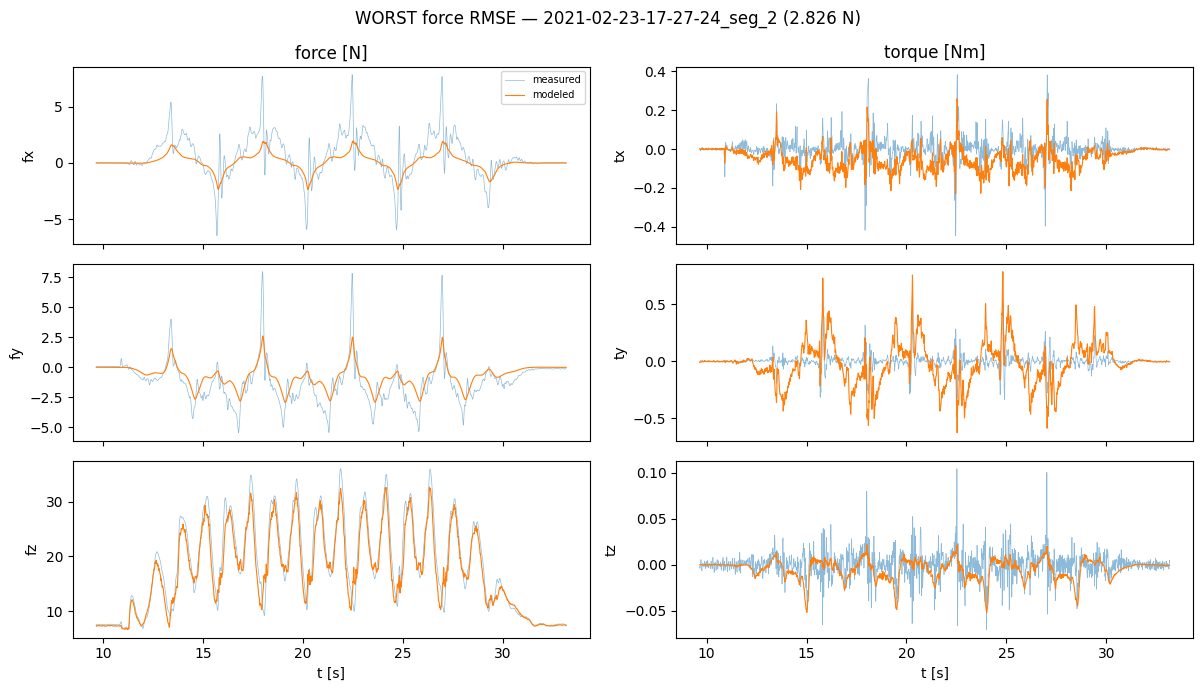

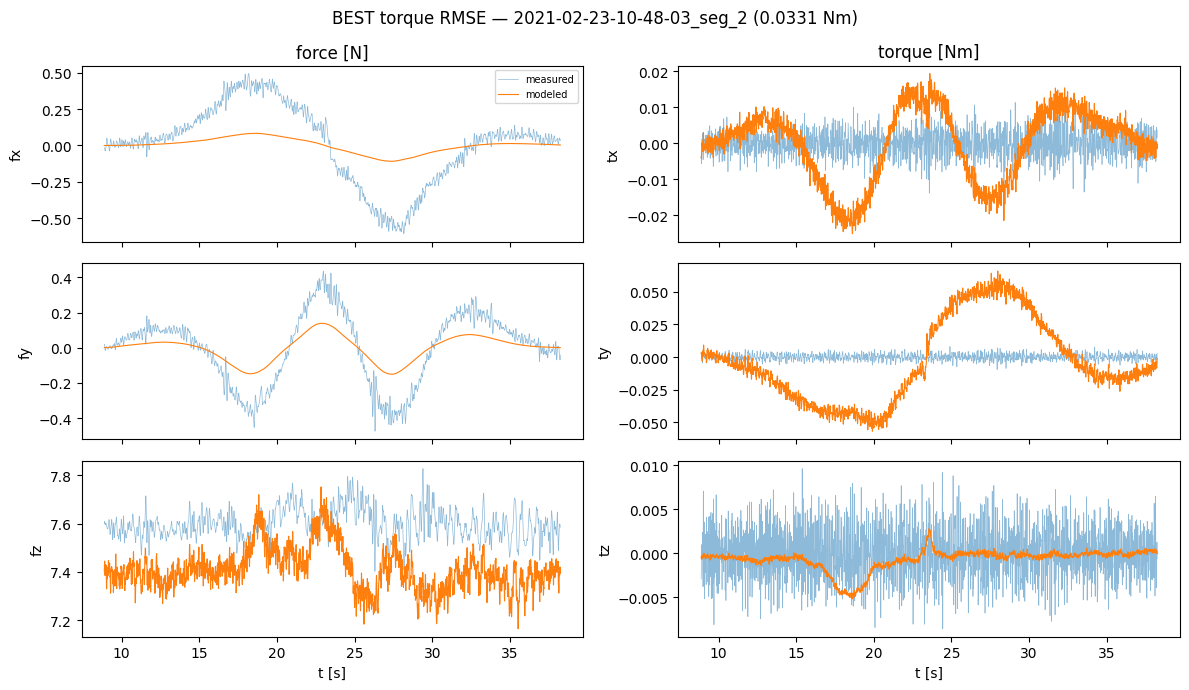

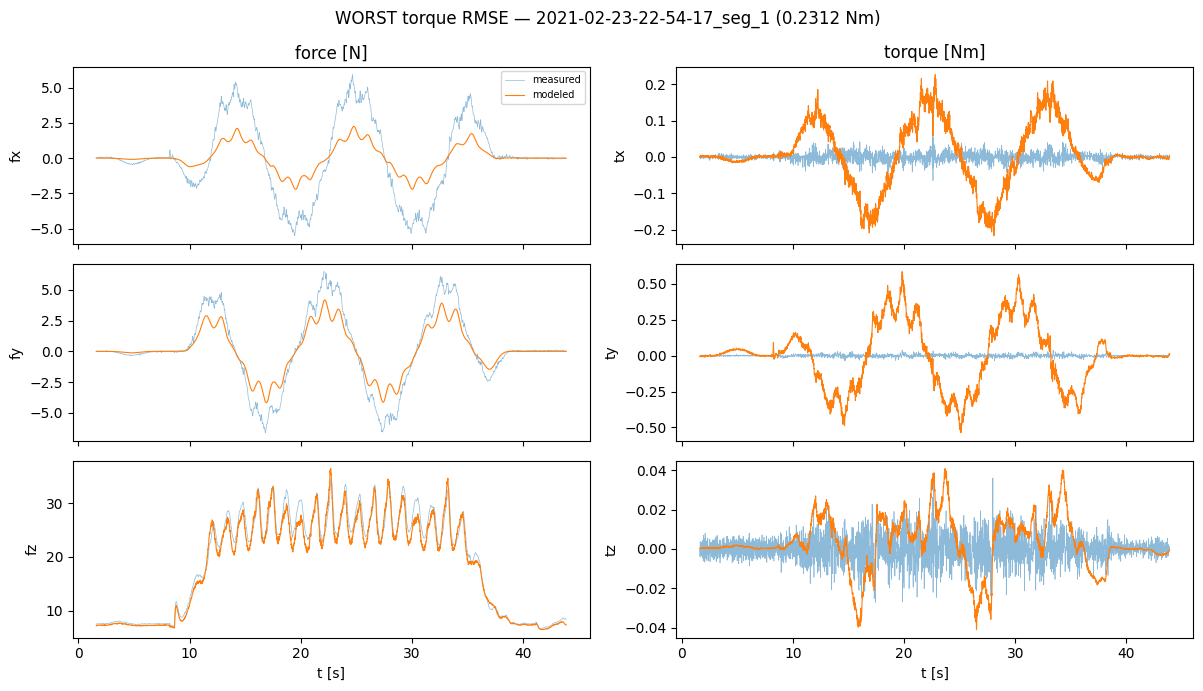

In [7]:
import matplotlib.pyplot as plt

RUN = "2026-07-22-18-39-25"
LABELS = ["fx", "fy", "fz", "tx", "ty", "tz"]


def seg_data(f):
    d = np.loadtxt(f, delimiter=",")
    fm, tm = measured(d)
    return d[:, 0], np.column_stack([fm, tm]), np.column_stack([d[:, 29:32], d[:, 32:35]])


seg = {}
for f in sorted(glob.glob(str(PROC / RUN / "*.csv"))):
    sid = os.path.basename(f).split("_", 1)[1][:-4]
    if sid not in TEST_IDS:
        continue
    t, meas, pred = seg_data(f)
    fr, tr = meas[:, :3] - pred[:, :3], meas[:, 3:] - pred[:, 3:]
    seg[sid] = dict(t=t, meas=meas, pred=pred,
                    frmse=np.sqrt((fr ** 2).sum(1).mean()),
                    trmse=np.sqrt((tr ** 2).sum(1).mean()))

sids = list(seg)
best_f = min(sids, key=lambda s: seg[s]["frmse"]);  worst_f = max(sids, key=lambda s: seg[s]["frmse"])
best_t = min(sids, key=lambda s: seg[s]["trmse"]);  worst_t = max(sids, key=lambda s: seg[s]["trmse"])


def plot_seg(sid, title):
    s = seg[sid]
    fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    for i, c in enumerate(LABELS):
        a = ax[i % 3, i // 3]
        a.plot(s["t"], s["meas"][:, i], lw=0.5, alpha=0.5, label="measured")
        a.plot(s["t"], s["pred"][:, i], lw=0.8, label="modeled")
        a.set_ylabel(c)
    ax[0, 0].set_title("force [N]"); ax[0, 1].set_title("torque [Nm]")
    ax[2, 0].set_xlabel("t [s]"); ax[2, 1].set_xlabel("t [s]")
    ax[0, 0].legend(loc="upper right", fontsize=7)
    fig.suptitle(title); fig.tight_layout()


plot_seg(best_f,  f"BEST force RMSE — {best_f} ({seg[best_f]['frmse']:.3f} N)")
plot_seg(worst_f, f"WORST force RMSE — {worst_f} ({seg[worst_f]['frmse']:.3f} N)")
plot_seg(best_t,  f"BEST torque RMSE — {best_t} ({seg[best_t]['trmse']:.4f} Nm)")
plot_seg(worst_t, f"WORST torque RMSE — {worst_t} ({seg[worst_t]['trmse']:.4f} Nm)")
